# Tutorial 3 - Student Excersise


## Setup


In [2]:
# Installing Preliz if necessary
!pip install preliz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.9/513.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.9/179.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.8 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0


In [3]:
%matplotlib inline
import arviz as az
import matplotlib.pyplot as plt
import pymc as pm
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns


In [4]:
import preliz as pz

In [5]:
az.style.use("arviz-darkgrid")
sns.set_style("darkgrid")

## Load data



In [6]:
#simulate data
email_data = stats.poisson(mu=8).rvs(size=24, random_state=17)
print(email_data)

n = len(email_data)
print(f'There are {n} participants')

S = np.sum(email_data)
print(f'There are a total of {S} emails')

[ 8  7  8  5  5 13  7  5 11  6 10 14  9 10 10  7 13  7  9  2  8  8 11  7]
There are 24 participants
There are a total of 200 emails


Text(0, 0.5, 'Counts')

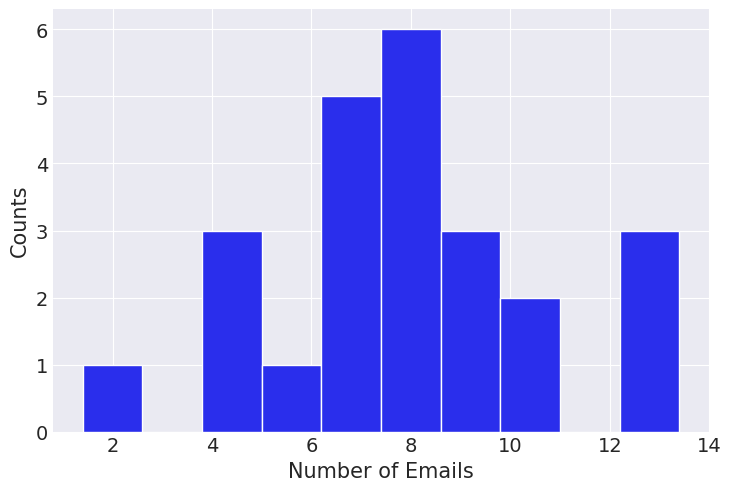

In [7]:
#look at the data
plt.hist(email_data, bins = 10, align = 'left')
plt.xlabel('Number of Emails')
plt.ylabel('Counts')

## Model

In [13]:
# Choosing a prior
# In Gamma the mean is determined by the relation between alpha (the "shape" parameter) and beta (the rate) - alpha/beta = mean
# I choose alpha = 64 and beta = 8
pz.Gamma(alpha=64, beta=8).plot_interactive()

interactive(children=(FloatSlider(value=64.0, description='alpha (0, inf)', max=160.0, min=2.220446049250313e-…

In [14]:
# Model
coords = {"emails": np.arange(n)}

with pm.Model(coords = coords) as email_model:
    lambda_ = pm.Gamma('lam', alpha = 64, beta = 8)
    k = pm.Poisson('k', mu = lambda_, observed=email_data, dims = 'emails')
    idata_email = pm.sample(1000, chains = 4, random_seed=17)

Output()

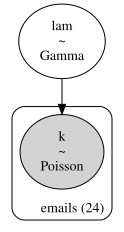

In [15]:
# Visualize dependencies
pm.model_to_graphviz(email_model)

### Analyzing the Posterior

array([[<Axes: title={'center': 'lam'}>, <Axes: title={'center': 'lam'}>]],
      dtype=object)

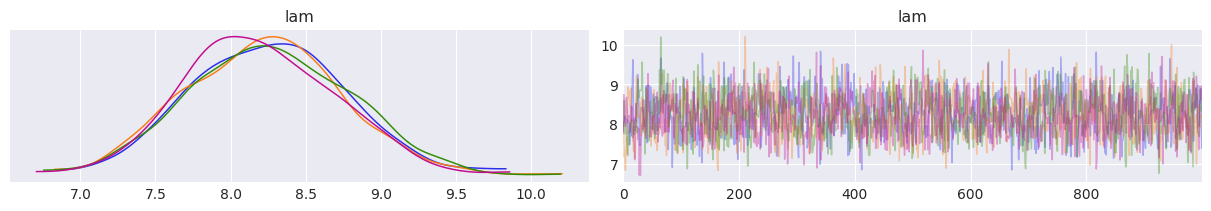

In [16]:
# trace plot
az.plot_trace(idata_email, compact = False)

<Axes: title={'center': 'lam'}>

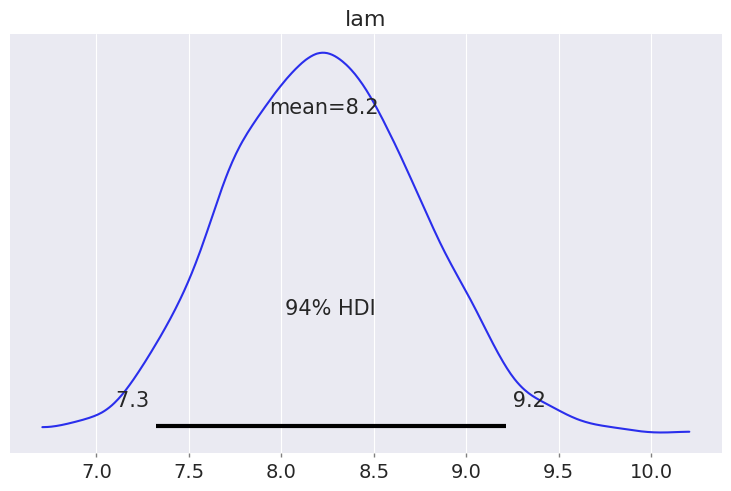

In [17]:
# Plotting the posterior distribution with the HDI
az.plot_posterior(idata_email)

In [18]:
#and getting the values in a table
az.summary(idata_email, kind = 'stats')

,mean,sd,hdi_3%,hdi_97%
lam,8.232,0.516,7.321,9.213
